In [1]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns

warnings.filterwarnings('ignore')

In [2]:
# Loading in the dataset of all predictions

summary = pd.read_csv("../output/summary_paddle_adhunter_adpred_pt_vars.csv")
summary

,Unnamed: 0,var,var_pred_paddle,wt_pred_paddle,var_pred_adhunter,wt_pred_adhunter,var_pos_adpred_activity,ref_pos_adpred_activity
0,0,SRCAP_Q6ZRS2_AD_198-1445|g.30710822A>T(p.Glu40...,0.147968,0.129918,24071.039062,23811.289062,NaN,NaN
1,1,SRCAP_Q6ZRS2_AD_198-1445|g.30721233C>T(p.Pro11...,-0.181365,-0.175508,42768.371094,43681.906250,NaN,NaN
2,2,SRCAP_Q6ZRS2_AD_198-1445|g.30721455G>A(p.Asp11...,-0.179097,-0.125538,46607.949219,48048.144531,NaN,NaN
3,3,SRCAP_Q6ZRS2_AD_198-1445|g.30723605C>T(p.Pro13...,-0.034244,-0.022734,29713.363281,32487.164062,NaN,NaN
4,4,SRCAP_Q6ZRS2_AD_198-1445|g.30720897C>A(p.Pro10...,-0.132803,-0.136810,38172.605469,38496.671875,NaN,NaN
...,...,...,...,...,...,...,...,...
3005,3005,NKX2-2_O95096_AD_220-273|g.21511967G>C(p.Pro26...,0.265297,0.236564,49325.363281,55944.699219,0.010054,0.009444
3006,3006,NKX2-2_O95096_AD_220-273|g.21512015G>A(p.His24...,0.279168,0.236564,52713.988281,52140.046875,0.012618,0.003549
3007,3007,NKX2-2_O95096_AD_220-273|g.21512041G>C(p.Ser23...,0.101297,0.197448,48869.820312,52295.695312,0.025123,0.016844
3008,3008,NKX2-2_O95096_AD_220-273|g.21512072C>T(p.Ala22...,0.321174,0.197448,49943.808594,52295.695312,0.016251,0.017796


In [3]:
# Adding in the original and new AA

summary["orig_AA"] = summary["var"].str.extract(r'p\.(...)')
summary["new_AA"] = summary["var"].str[-4:-1]

# Converting to 1 letter code
aa_dict = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C',
    'Glu': 'E', 'Gln': 'Q', 'Gly': 'G', 'His': 'H', 'Ile': 'I',
    'Leu': 'L', 'Lys': 'K', 'Met': 'M', 'Phe': 'F', 'Pro': 'P',
    'Ser': 'S', 'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V'
}

summary["orig_AA"] = summary["orig_AA"].map(aa_dict)
summary["new_AA"] = summary["new_AA"].map(aa_dict)
summary

,Unnamed: 0,var,var_pred_paddle,wt_pred_paddle,var_pred_adhunter,wt_pred_adhunter,var_pos_adpred_activity,ref_pos_adpred_activity,orig_AA,new_AA
0,0,SRCAP_Q6ZRS2_AD_198-1445|g.30710822A>T(p.Glu40...,0.147968,0.129918,24071.039062,23811.289062,NaN,NaN,E,D
1,1,SRCAP_Q6ZRS2_AD_198-1445|g.30721233C>T(p.Pro11...,-0.181365,-0.175508,42768.371094,43681.906250,NaN,NaN,P,S
2,2,SRCAP_Q6ZRS2_AD_198-1445|g.30721455G>A(p.Asp11...,-0.179097,-0.125538,46607.949219,48048.144531,NaN,NaN,D,N
3,3,SRCAP_Q6ZRS2_AD_198-1445|g.30723605C>T(p.Pro13...,-0.034244,-0.022734,29713.363281,32487.164062,NaN,NaN,P,L
4,4,SRCAP_Q6ZRS2_AD_198-1445|g.30720897C>A(p.Pro10...,-0.132803,-0.136810,38172.605469,38496.671875,NaN,NaN,P,T
...,...,...,...,...,...,...,...,...,...,...
3005,3005,NKX2-2_O95096_AD_220-273|g.21511967G>C(p.Pro26...,0.265297,0.236564,49325.363281,55944.699219,0.010054,0.009444,P,A
3006,3006,NKX2-2_O95096_AD_220-273|g.21512015G>A(p.His24...,0.279168,0.236564,52713.988281,52140.046875,0.012618,0.003549,H,Y
3007,3007,NKX2-2_O95096_AD_220-273|g.21512041G>C(p.Ser23...,0.101297,0.197448,48869.820312,52295.695312,0.025123,0.016844,S,C
3008,3008,NKX2-2_O95096_AD_220-273|g.21512072C>T(p.Ala22...,0.321174,0.197448,49943.808594,52295.695312,0.016251,0.017796,A,T


In [6]:
# cmap_bound = max(abs(max(summary["activ_diff_" + predictor_name + " mean"])),
#                 abs(min(summary["activ_diff_" + predictor_name + " mean"])))


In [211]:
def plot_a_heatmap(summary_df, predictor_name, var_col_name, ref_col_name, ax, cbar = True):
    sns.set_context('paper')
    sns.set_style("white")

    # Calculating activitoy difference
    summary_df["activ_diff_" + predictor_name] = summary_df[var_col_name] - summary_df[ref_col_name]

    # Z-scores
    summary_df["activ_diff_" + predictor_name] = (summary_df["activ_diff_" + predictor_name] - np.mean(summary_df["activ_diff_" + predictor_name])) / np.std(summary_df["activ_diff_" + predictor_name])
    relev_cols = summary_df[["orig_AA", "new_AA", "activ_diff_" + predictor_name]]
    
    # Making a matrix  to prepare for heatmap
    relev_cols = relev_cols.groupby(["orig_AA", "new_AA"]).agg(['mean', 'count']).reset_index()
    relev_cols.columns = [' '.join(col).strip() for col in relev_cols.columns.values]

    #display(relev_cols)
    # Formatting as pivot table where values are averages
    pivot_relev_cols = pd.pivot(relev_cols, values = "activ_diff_" + predictor_name + " mean", 
                                                index = "new_AA", columns = "orig_AA")

    # format rows and cols in this order
    AA_order = ["D", "E", "R", "K", "W", "F", "Y", "L", "M", "I", "V", "A", "S", "T", "N", "Q", "H", "C", "G", "P"]
    pivot_relev_cols = pivot_relev_cols.reindex(AA_order, axis = 0)
    pivot_relev_cols = pivot_relev_cols.reindex(AA_order, axis = 1)

    # cmap_bound = max(abs(max(relev_cols["activ_diff_" + predictor_name + " mean"])),
    #                  abs(min(relev_cols["activ_diff_" + predictor_name + " mean"])))
    # print(cmap_bound)

    # Based on printing out for all
    cmap_bound = 4.76
    
    if cbar:
        sns.heatmap(pivot_relev_cols, ax = ax, 
                    cmap = "coolwarm", 
                    vmin = -1 * cmap_bound, 
                    vmax = cmap_bound, 
                    cbar_kws = dict(location="right", label = "Average Variant Activity Difference", pad  = 0.01))
    else:
        sns.heatmap(pivot_relev_cols, ax = ax, 
                    cmap = "coolwarm", 
                    vmin = -1 * cmap_bound, 
                    vmax = cmap_bound, 
                    cbar = False)

    for i in np.arange(21):
        ax.axvline(i, color = 'black', lw = 0.05)
        ax.axhline(i, color = 'black', lw = 0.05)
    ax.axhline(0, color = 'black', lw = 1)
    ax.axhline(20, color = 'black', lw = 1)
    ax.axvline(0, color = 'black', lw = 1)
    ax.axvline(20, color = 'black', lw = 1)

    # plt.yticks(rotation = 0)
    # plt.xlabel("Reference")
    # plt.ylabel("Variant")
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title(predictor_name, pad = 2, fontsize = 'x-large')
    #plt.show()

    


In [212]:
AA_order = ["D", "E", "R", "K", "W", "F", "Y", "L", "M", "I", "V", "A", "S", "T", "N", "Q", "H", "C", "G", "P"]


Text(-0.01, 0.5, 'Variant')

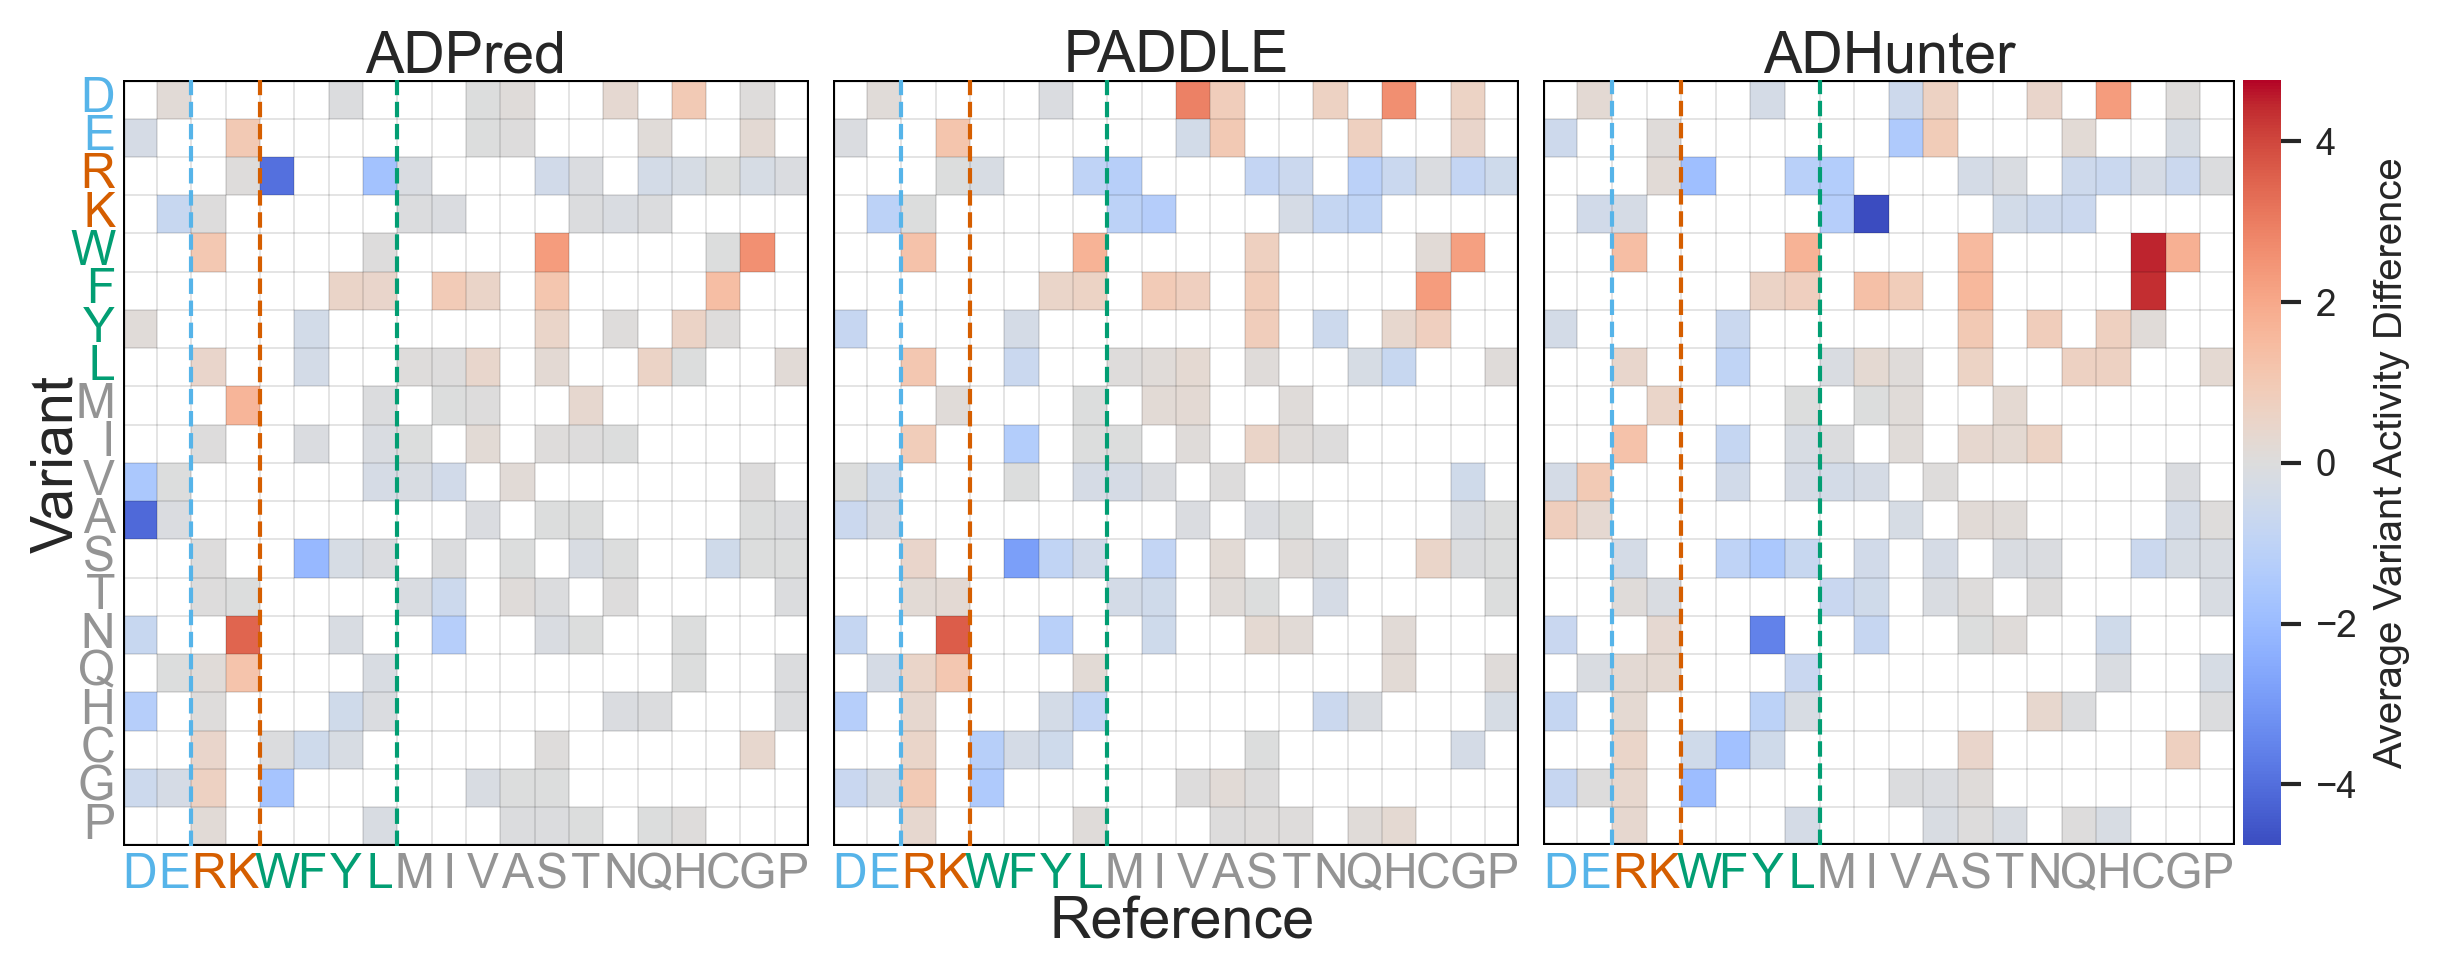

In [216]:
fig, axs = plt.subplots(1,3, figsize=(8, 3), dpi = 300, sharey = True, width_ratios = [1,1,1.2])
plot_a_heatmap(summary, "ADPred", "var_pos_adpred_activity", "ref_pos_adpred_activity", ax = axs[0], cbar = False)




plot_a_heatmap(summary, "PADDLE", "var_pred_paddle", "wt_pred_paddle", ax = axs[1], cbar = False)
plot_a_heatmap(summary, "ADHunter", "var_pred_adhunter", "wt_pred_adhunter", ax = axs[2])


for ax in axs:
    ax.set_xticks(np.arange(20) + 0.5, AA_order)
    ax.set_yticks(np.arange(20) + 0.5, AA_order)
    ax.tick_params(axis='x', which='major', tick1On=False, tick2On=False, pad=-3, labelsize = 'large')
    ax.tick_params(axis='y', which='major', tick1On=False, tick2On=False, pad=-3, labelsize = 'large', rotation = 0)



    de_color = sns.color_palette('colorblind')[-1]
    rk_color = sns.color_palette('colorblind')[3]
    wfyl_color = sns.color_palette('colorblind')[2]
    other_color = sns.color_palette('colorblind')[-3]

    ax.axvline(2, color = de_color, lw = 1, linestyle = 'dashed')
    ax.axvline(4, color = rk_color, lw = 1, linestyle = 'dashed')
    ax.axvline(8, color = wfyl_color, lw = 1, linestyle = 'dashed')

    colors = [de_color, de_color,
                rk_color, rk_color,
                wfyl_color, wfyl_color,
                wfyl_color, wfyl_color, 
                other_color, other_color, 
                other_color, other_color, 
                other_color, other_color, 
                other_color, other_color, 
                other_color, other_color, 
                other_color, other_color]
    for xtick, color in zip(ax.get_xticklabels(), colors):
        xtick.set_color(color)
        
    for ytick, color in zip(ax.get_yticklabels(), colors):
        ytick.set_color(color)

plt.tight_layout(pad = 0.4)

fig.supxlabel("Reference", y = -0.04, x = 0.47, fontsize = 'x-large')
fig.supylabel("Variant", x = -0.01, fontsize = 'x-large')

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]